In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Necessary imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
cd /content/drive/MyDrive/Machine learning 2024/Notebooks - ANN - DNN/5.Brain tumor project using CNN/brain tumor dataset

/content/drive/MyDrive/Machine learning 2024/Notebooks - ANN - DNN/5.Brain tumor project using CNN/brain tumor dataset


# Let's visualize the data.

In [ ]:
data_dir = ('Training')
categories = ['glioma', 'meningioma', 'notumor', 'pituitary']
for i in categories:
    path = os.path.join(data_dir, i)  #Training/glioma
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path,img)) #Training/glioma/abc.jpeg
        break
    break

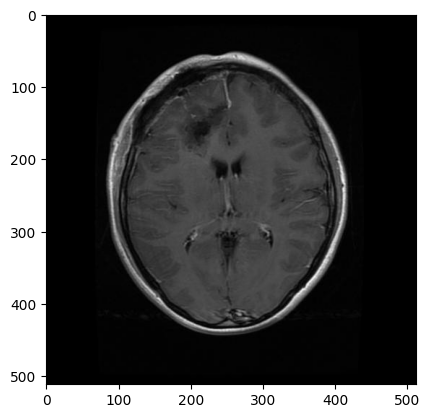

In [ ]:
plt.imshow(img_array)

In [ ]:
# The image shape.
img_array.shape

(512, 512, 3)

#### Ploting a image of each brain tumor type

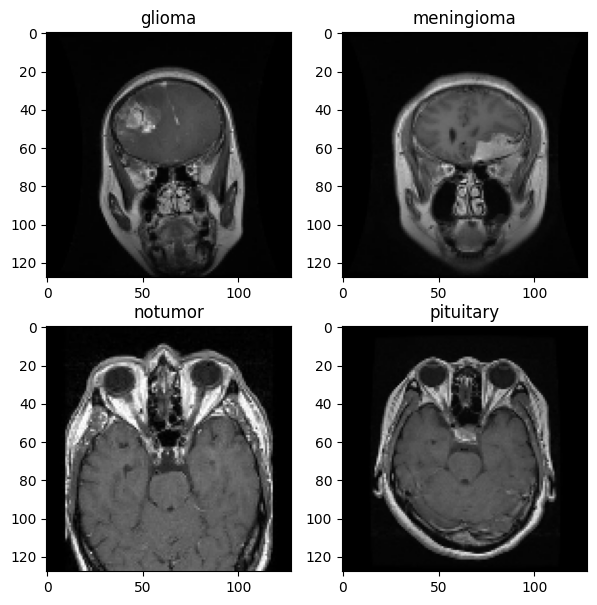

In [ ]:
plt.figure(figsize=(7, 7))

images_path = ['/glioma/Tr-glTr_0000.jpg', '/meningioma/Tr-meTr_0000.jpg',
               '/notumor/Tr-noTr_0000.jpg', '/pituitary/Tr-piTr_0000.jpg']

for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    img = cv2.imread(data_dir + images_path[i])
    img = cv2.resize(img, (128, 128))
    plt.imshow(img)
    plt.title(categories[i])

# Modelling


# CNN - Model

In [ ]:
model = Sequential()

# Convolutional layer 1
model.add(Conv2D(64,(7,7), input_shape=(128, 128, 1), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

#Convolutional layer 2
model.add(Conv2D(128,(7,7), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional layer 3
model.add(Conv2D(128,(7,7), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional layer 4
model.add(Conv2D(256,(7,7), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

 # Convolutional layer 5
model.add(Conv2D(256,(7,7), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional layer 6
model.add(Conv2D(512,(7,7), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

# Full connect layers

model.add(Dense(units= 1024, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units=512, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units=4, activation='softmax'))


from tensorflow.keras.optimizers import SGD
model.compile(optimizer="adam", loss='categorical_crossentropy',
                   metrics= ['accuracy',keras.metrics.Precision(),
                             keras.metrics.Recall(),
                             keras.metrics.SpecificityAtSensitivity(0.5),
                             keras.metrics.SensitivityAtSpecificity(0.5)])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# using the ImageDataGenerator to prepare the images (Resize, nomalize, etc)

generator_train = ImageDataGenerator(rescale=1./255,
                                     validation_split=0.15,
                                    featurewise_center=False,
                                    samplewise_center=False,
                                    featurewise_std_normalization=False,
                                    samplewise_std_normalization=False,
                                    zca_whitening=False,
                                    rotation_range=0,
                                    zoom_range = 0,
                                    width_shift_range=0,
                                    height_shift_range=0,
                                    horizontal_flip=True,
                                    vertical_flip=False)

generator_test = ImageDataGenerator(rescale=1./255,
                                  )

# Creating the train and test data.

train = generator_train.flow_from_directory('Training', target_size=(128,128),subset="training",
                                              batch_size=32, class_mode= "categorical", color_mode='grayscale')

val = generator_train.flow_from_directory('Training', target_size=(128,128),subset="validation",
                                              batch_size=32, class_mode= "categorical", color_mode='grayscale')

test = generator_test.flow_from_directory('Testing', target_size=(128,128),
                                              batch_size=32, class_mode= "categorical", color_mode='grayscale')

Found 5368 images belonging to 4 classes.
Found 945 images belonging to 4 classes.
Found 720 images belonging to 4 classes.


In [ ]:
for i in range(5):
    print(test[i][1][0].tolist())

[0.0, 1.0, 0.0, 0.0]
[0.0, 1.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 1.0]
[0.0, 1.0, 0.0, 0.0]
[1.0, 0.0, 0.0, 0.0]


### Trainig model 1

In [ ]:
# Creating callbacks for the model.
# If the model dosen't continue to improve (loss), the trainning will stop.

# Stop training if loss doesn't keep decreasing.
model1_es = EarlyStopping(monitor = 'val_loss', min_delta = 1e-11, patience = 10, verbose = 1)
model1_rlr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 6, verbose = 1)

# Automatically saves the best weights of the model, based on best val_accuracy
model1_mcp = ModelCheckpoint(filepath = 'model_1_CNN.keras', monitor = 'val_accuracy',
                      save_best_only = True, verbose = 1)

In [ ]:
# Fiting the model.
history1 = model.fit(train, epochs=70, validation_data=val,
                     callbacks=[model1_es, model1_rlr, model1_mcp])

Epoch 1/70
168/168 [==============================] - ETA: 0s - loss: 0.6776 - accuracy: 0.7468 - precision: 0.7805 - recall: 0.7122 - specificity_at_sensitivity: 0.9762 - sensitivity_at_specificity: 0.9763
Epoch 1: val_accuracy improved from -inf to 0.24974, saving model to model1_weights.h5
168/168 [==============================] - 52s 221ms/step - loss: 0.6776 - accuracy: 0.7468 - precision: 0.7805 - recall: 0.7122 - specificity_at_sensitivity: 0.9762 - sensitivity_at_specificity: 0.9763 - val_loss: 1.4219 - val_accuracy: 0.2497 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_specificity_at_sensitivity: 0.5228 - val_sensitivity_at_specificity: 0.5450 - lr: 0.0010
Epoch 2/70
168/168 [==============================] - ETA: 0s - loss: 0.4157 - accuracy: 0.8361 - precision: 0.8525 - recall: 0.8171 - specificity_at_sensitivity: 0.9935 - sensitivity_at_specificity: 0.9970
Epoch 2: val_accuracy improved from 0.24974 to 0.41587, saving model to model1_weights.h5
168/168 [=======

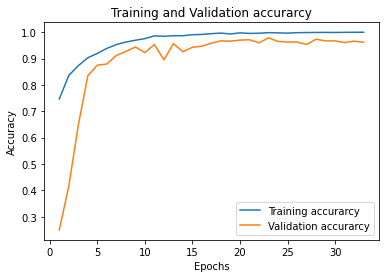

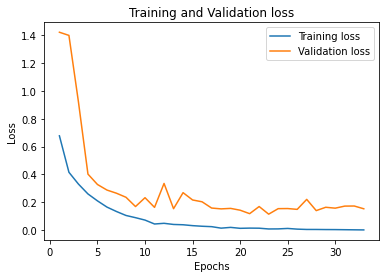

In [ ]:
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']
loss = history1.history['loss']
val_loss = history1.history['val_loss']
epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, label='Training accurarcy')
plt.plot(epochs, val_acc, label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# load the model

from tensorflow import keras
model = keras.models.load_model('model_1_CNN.keras')


In [ ]:
model.evaluate(test)

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 231s 10s/step - accuracy: 0.9931 - loss: 0.0394 - precision: 0.9931 - recall: 0.9931 - sensitivity_at_specificity: 0.9988 - specificity_at_sensitivity: 0.9999


[0.06831677258014679,
 0.9861111044883728,
 0.9861111044883728,
 0.9861111044883728,
 0.9995370507240295,
 0.9972222447395325]

In [ ]:
from tqdm import tqdm
import numpy as np
y_test = []
y_test_int = []
for i in tqdm(range(len(test))):
    y_test += test[i][1].tolist()
    y_test_int += test[i][1].argmax(axis=1).tolist()

y_test = np.array(y_test)
y_test_int = np.array(y_test_int)

100%|██████████| 23/23 [00:06<00:00,  3.48it/s]


In [ ]:
target_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 239ms/step
Accuracy is:  0.9861111111111112


<Axes: >

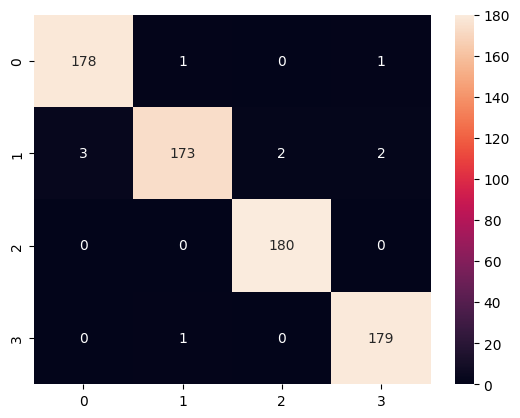

In [ ]:
#Creating a confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

y_pred_test = model.predict(test, verbose=1)
y_pred_test_int = y_pred_test.argmax(axis=1)


ac = accuracy_score(y_test_int, y_pred_test_int)
print('Accuracy is: ',ac)
cm = confusion_matrix(y_test_int, y_pred_test_int)
sn.heatmap(cm,annot=True,fmt="d")

In [ ]:
from sklearn.metrics import classification_report
target_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(y_test_int, y_pred_test_int, target_names=target_names, digits=4))

              precision    recall  f1-score   support

      glioma     0.9834    0.9889    0.9861       180
  meningioma     0.9886    0.9611    0.9746       180
     notumor     0.9890    1.0000    0.9945       180
   pituitary     0.9835    0.9944    0.9890       180

    accuracy                         0.9861       720
   macro avg     0.9861    0.9861    0.9861       720
weighted avg     0.9861    0.9861    0.9861       720



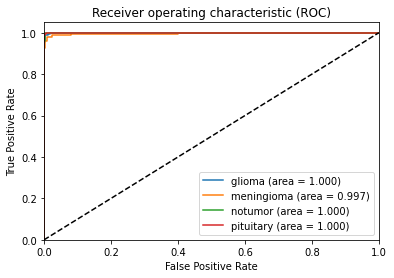

In [ ]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot of a ROC curve for each class
plt.figure()
classes=['glioma', 'meningioma', 'notumor', 'pituitary']
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='{} (area = {:0.3f})'.format(classes[i], roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Select any image from test folder and test it using the louded model

import numpy as np
import cv2
from tensorflow.keras.preprocessing import image

# Load the image
img_path = 'Testing/glioma/Te-gl_0030.jpg'  # Replace with the actual image path
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (128, 128))
img = image.img_to_array(img)
img = img / 255.0  # Normalize the image
img = np.expand_dims(img, axis=0)  #convert from (128, 128, 1) to (1, 128, 128, 1).

# Make a prediction
prediction = model.predict(img)

# Get the predicted class
predicted_class = np.argmax(prediction)

# Print the prediction
print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class: 0


In [ ]:
# prompt: Predicted class: 0 for what classs ?

# The predicted class 0 corresponds to 'glioma'.
# This is because the model's output is a probability distribution
# over the classes, and the class with the highest probability is
# selected as the prediction. In this case, the model predicted that
# the image belongs to the 'glioma' class with the highest probability.


In [ ]:
# what is the order of classes

print(train.class_indices)


{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
